## Imports and Constants/Experiment Setup

In [3]:
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

import uconn_ballots_dino_v3_model
import uccon_ballots_dataset
from warmup_cosine_annealing_lr import WarmupCosineAnnealingLR
from validate_uconn_dataset import validate_uconn
from train_helper_funcs import ProgressTracker, CheckpointManager, _count_correct, _compute_accuracy


DATASET_ROOT = "./uconn_voter_center_v2_2/FINALDATASETV3/preprint/" # Path to the root directory containing the dataset .pth files, using preprint version as default
VARIANT = "Combined_Grayscale" # Options: "Combined_Grayscale", "Combined_RGB", "OnlyBubbles_Grayscale", "OnlyBubbles_RGB", etc

# CHECKPOINTING
SAVE_CHECKPOINTS = True
CHECKPOINT_DIR = "./checkpoints/"
CHECKPOINT_MODE = "best"  # Options: "best", "last", "both"

## Validate Model/Dataset

Validating UConn Grayscale Dataset...
Dataset length: 42679
Sample shape: torch.Size([1, 40, 50]), Label: 1
Loaded test split from D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3\split_Combined_Grayscale.txt (1000 samples)
Variant:    Combined_Grayscale  |  channels: 1
Train size: 42679
Val size:   9652
Test size:  1000
Root:       D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3

Validating DINOv3 UConn Model...


d:\MLSEC-Final\CSC592-MLSEC-InstantPure\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Output shape: torch.Size([1, 2])
Output: tensor([[-0.1912,  0.2508]], grad_fn=<AddmmBackward0>)

Displaying sample images from the dataset...


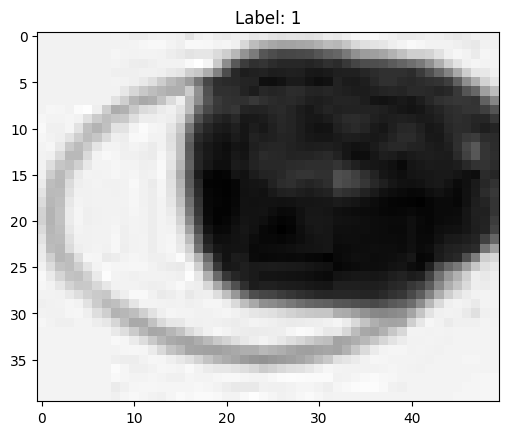

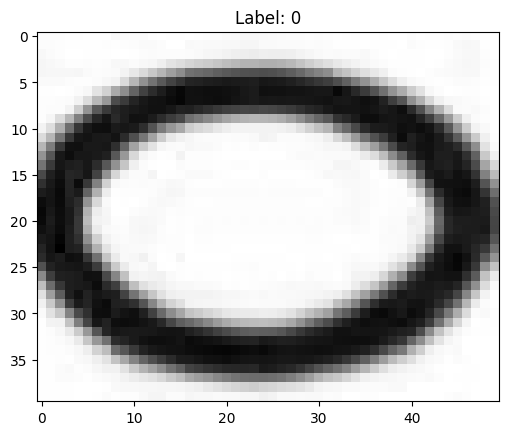

In [2]:
validate_uconn(root=DATASET_ROOT, variant=VARIANT)

## Training Config and DataLoaders

In [8]:
# Train Config:
config = {
    "batch_size": 32,
    "num_epochs": 20,
    "learning_rate": 0.001,
    "num_workers": 8,
    "pin_memory": False,
    "persistent_workers": True,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "criterion": torch.nn.CrossEntropyLoss(),
    "num_warmup_epochs": 5,
    "T_max": 20,
    "eta_min": 1e-6,
}

# Define data augmentations:
augmentations = None

# Get DataLoaders:
train_loader, val_loader, test_loader = uccon_ballots_dataset.get_uconn_dataloaders(
    batch_size=config["batch_size"],
    test_size=1000,
    test_source="val",
    variant=VARIANT,
    transform=augmentations,
    num_workers=config["num_workers"],
    pin_memory=config["pin_memory"],
    persistent_workers=config["persistent_workers"],
    seed=42,
)


Loaded test split from D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3\split_Combined_Grayscale.txt (1000 samples)
Variant:    Combined_Grayscale  |  channels: 1
Train size: 42679
Val size:   9652
Test size:  1000
Root:       D:\MLSEC-Final\CSC592-MLSEC-InstantPure\uconn_voter_center_v2_2\FINALDATASETV3


## Model Training

In [4]:
# Build Model:
model = uconn_ballots_dino_v3_model.DINOv3UConnModel(num_classes=2)
model = model.to(config["device"])

# Set up optimizer, criterion, and scheduler:
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])
criterion = config["criterion"]
#scheduler = WarmupCosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6, start_factor=0.1, warmup_iters=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["T_max"], eta_min=config["eta_min"])

# Pull out some config values for convenience:
epochs = config["num_epochs"]
device = config["device"]

# Set up checkpoint manager:
checkpoint_config = {
     "enabled": SAVE_CHECKPOINTS,
     "mode": CHECKPOINT_MODE,
     "dir": CHECKPOINT_DIR,
     "monitor": "val_loss",
     "every_n_epochs": 1,
}

checkpoint_manager = CheckpointManager(checkpoint_config, CHECKPOINT_DIR)

# ====== Training Loop ====== #
for epoch in range(epochs):
        # Set model to training mode
        model.train()
        # Initialize metrics
        train_loss = 0.0
        train_correct = 0
        train_samples = 0

        # Create a progress tracker for the training loop
        tracker = ProgressTracker(len(train_loader))

        # Iterate over training batches
        for batch_idx, batch in enumerate(train_loader):
            # Move data to the appropriate device
            data, target, *_ = batch
            data, target = data.to(device), target.to(device)
            
            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            preds = model(data)
            # Compute loss
            loss = criterion(preds, target)
            train_loss += loss.item()

            # Backward pass and optimization step
            loss.backward()
            optimizer.step()

            # Update training metrics
            train_correct += _count_correct(preds, target)
            train_samples += target.size(0)

            # Update progress tracker
            tracker.update(batch_idx)

        # Finish progress tracking for the epoch
        tracker.finish()

        # Set model to evaluation mode and initialize validation metrics
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_samples = 0

        # Evaluate on validation set without tracking gradients
        with torch.inference_mode():
            for batch in val_loader:
                data, target, *_ = batch
                data, target = data.to(device), target.to(device)

                # Forward pass
                preds = model(data)

                # Compute loss
                loss = criterion(preds, target)
                val_loss += loss.item()

                # Update validation metrics
                val_correct += _count_correct(preds, target)
                val_samples += target.size(0)

        # Compute mean losses and accuracies
        mean_train_loss = train_loss / len(train_loader)
        mean_val_loss = val_loss / len(val_loader)
        train_acc = _compute_accuracy(train_correct, train_samples)
        val_acc = _compute_accuracy(val_correct, val_samples)

        epoch_metrics = {
            "train_loss": mean_train_loss,
            "val_loss": mean_val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
        }

        scheduler.step()
        checkpoint_manager.step(epoch, model, optimizer, scheduler, epoch_metrics)

        print(
            f"EPOCH: {epoch} | "
            f"Train Loss: {mean_train_loss:.4f} | Train Acc: {train_acc:.4%} | "
            f"Val Loss: {mean_val_loss:.4f} | Val Acc: {val_acc:.4%}"
        )

1334/1334 | batch 0.029s | avg 0.038s | eta 0.0ss
EPOCH: 0 | Train Loss: 0.5128 | Train Acc: 74.1957% | Val Loss: 0.4550 | Val Acc: 82.7704%
1334/1334 | batch 0.027s | avg 0.036s | eta 0.0ss
EPOCH: 1 | Train Loss: 0.3658 | Train Acc: 84.0812% | Val Loss: 0.2181 | Val Acc: 92.7683%
1334/1334 | batch 0.028s | avg 0.036s | eta 0.0ss
EPOCH: 2 | Train Loss: 0.2747 | Train Acc: 89.1141% | Val Loss: 0.1841 | Val Acc: 92.8823%
1334/1334 | batch 0.028s | avg 0.036s | eta 0.0ss
EPOCH: 3 | Train Loss: 0.2325 | Train Acc: 90.9792% | Val Loss: 0.3317 | Val Acc: 87.0286%
1334/1334 | batch 0.027s | avg 0.036s | eta 0.0ss
EPOCH: 4 | Train Loss: 0.2009 | Train Acc: 92.5678% | Val Loss: 0.2363 | Val Acc: 92.0845%
1334/1334 | batch 0.028s | avg 0.036s | eta 0.0ss
EPOCH: 5 | Train Loss: 0.1784 | Train Acc: 93.3363% | Val Loss: 0.1193 | Val Acc: 94.9648%
1334/1334 | batch 0.028s | avg 0.036s | eta 0.0ss
EPOCH: 6 | Train Loss: 0.1667 | Train Acc: 93.8119% | Val Loss: 0.1385 | Val Acc: 94.3328%
1334/1334 | b

## Model Testing

In [5]:
# Set model to evaluation mode and initialize test metrics
model.eval()
test_loss = 0.0
test_correct = 0
test_samples = 0

# Evaluate on test set without tracking gradients
with torch.inference_mode():
    for batch in test_loader:
        data, target, *_ = batch
        data, target = data.to(device), target.to(device)

        preds = model(data)
        loss = criterion(preds, target)
        test_loss += loss.item()

        test_correct += _count_correct(preds, target)
        test_samples += target.size(0)

mean_test_loss = test_loss / len(test_loader)
test_acc = _compute_accuracy(test_correct, test_samples)

print(f"TEST Loss: {mean_test_loss:.4f} | Test Acc: {test_acc:.4%}")

TEST Loss: 0.0646 | Test Acc: 96.9000%


In [12]:
# Load best model for final evaluation on test set

best_model_path = "./checkpoints/checkpoints/best.pt"
best_model = uconn_ballots_dino_v3_model.DINOv3UConnModel(num_classes=2)
best_model.load_state_dict(torch.load(best_model_path)["model_state_dict"])
best_model = best_model.to('cuda' if torch.cuda.is_available() else 'cpu')
best_model.eval()

criterion = config["criterion"]

test_loss = 0.0
test_correct = 0
test_samples = 0
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Evaluate on test set without tracking gradients
with torch.inference_mode():
    for batch in test_loader:
        data, target, *_ = batch
        data, target = data.to(device), target.to(device)

        preds = best_model(data)
        loss = criterion(preds, target)
        test_loss += loss.item()

        test_correct += _count_correct(preds, target)
        test_samples += target.size(0)

mean_test_loss = test_loss / len(test_loader)
test_acc = _compute_accuracy(test_correct, test_samples)

print(f"TEST Loss: {mean_test_loss:.4f} | Test Acc: {test_acc:.4%}")


TEST Loss: 0.0525 | Test Acc: 98.4000%


True Label: 0 | Predicted Label: 0


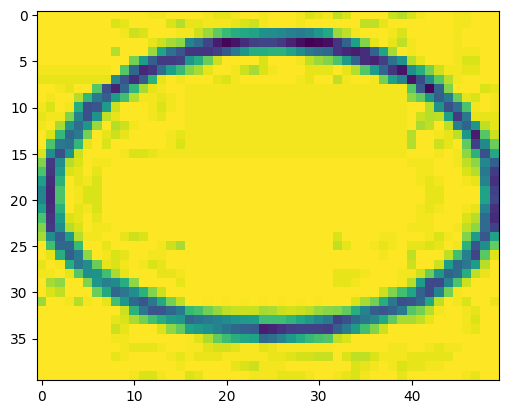

True Label: 0 | Predicted Label: 0


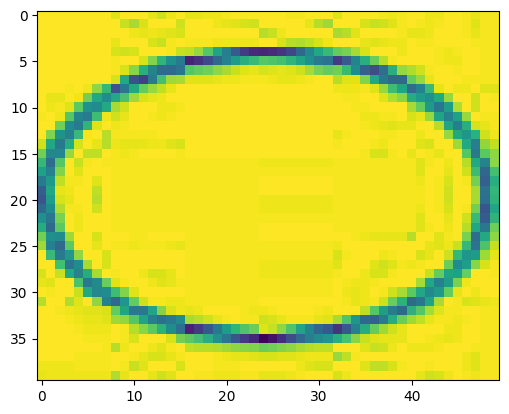

True Label: 0 | Predicted Label: 0


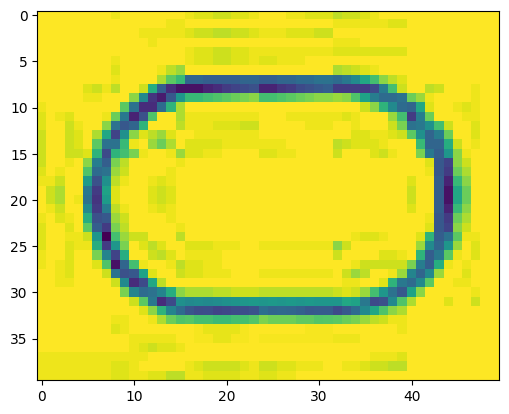

True Label: 1 | Predicted Label: 1


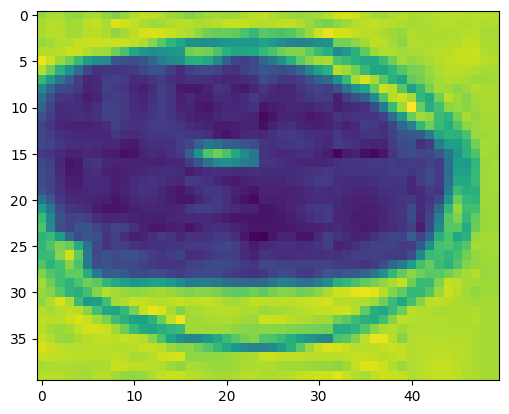

True Label: 0 | Predicted Label: 0


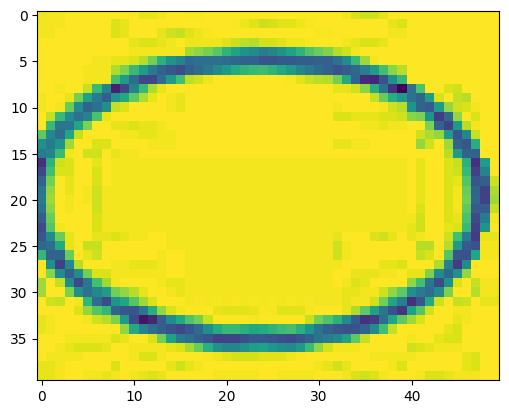

True Label: 1 | Predicted Label: 1


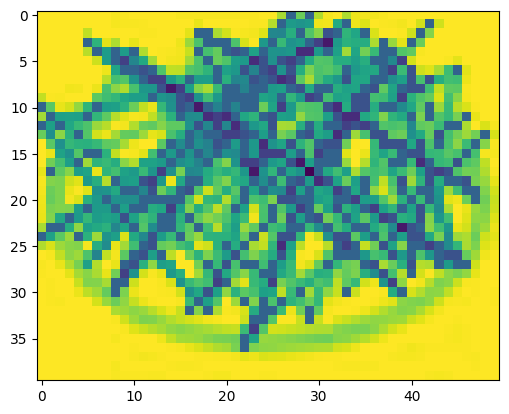

True Label: 0 | Predicted Label: 0


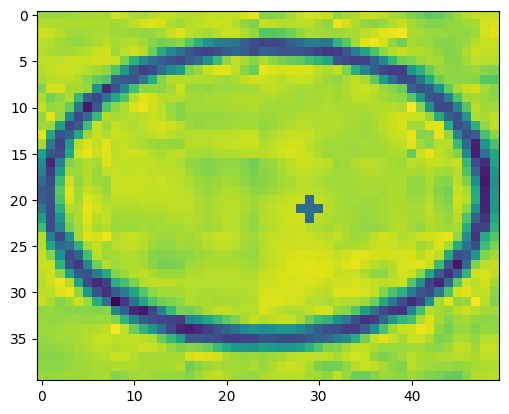

True Label: 1 | Predicted Label: 1


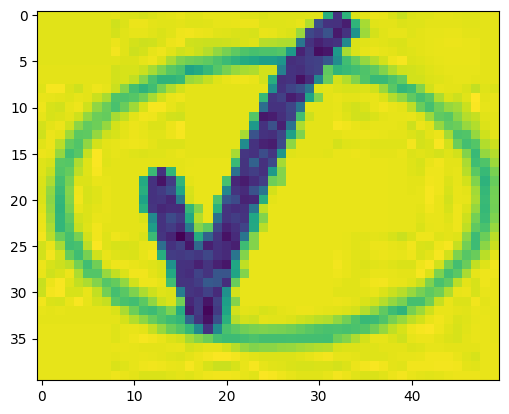

True Label: 0 | Predicted Label: 0


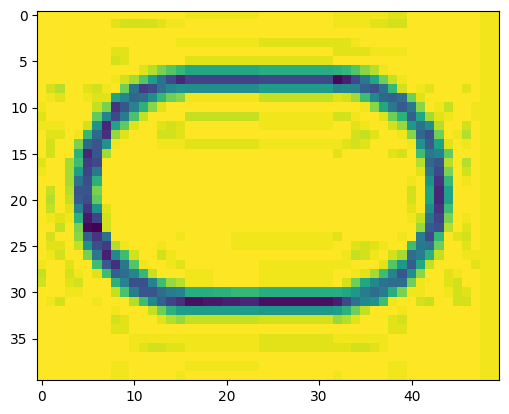

True Label: 1 | Predicted Label: 1


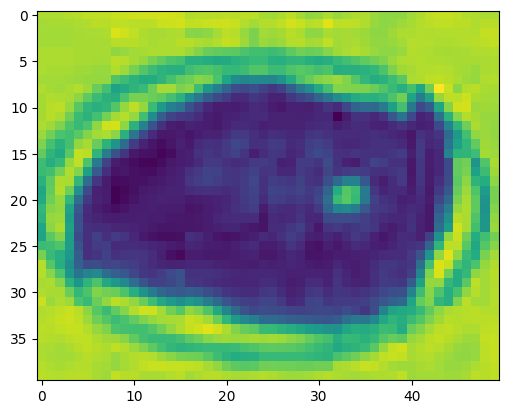

True Label: 0 | Predicted Label: 0


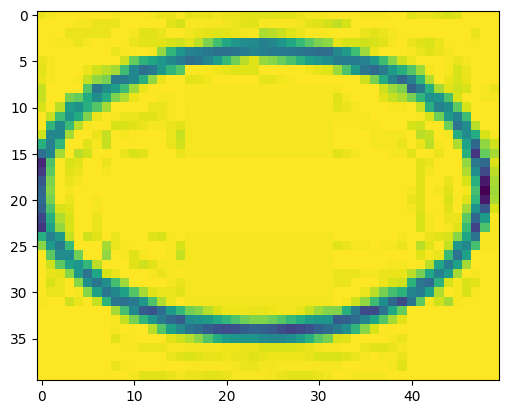

True Label: 0 | Predicted Label: 0


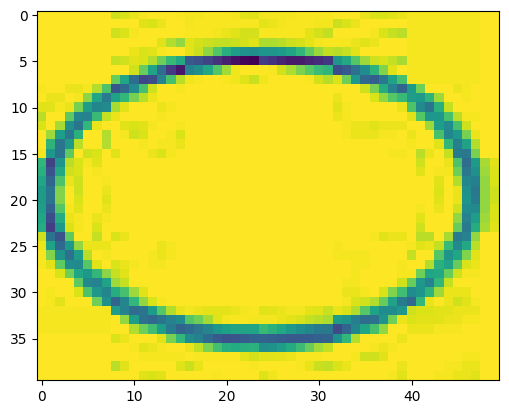

True Label: 1 | Predicted Label: 1


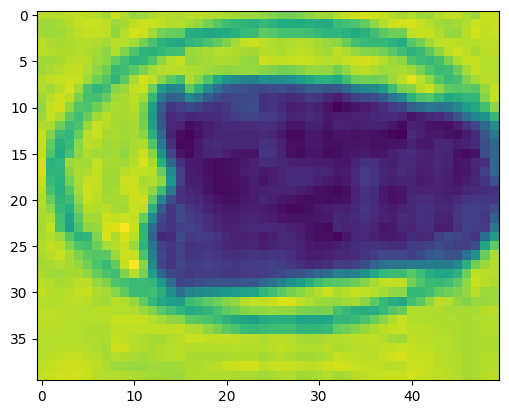

True Label: 1 | Predicted Label: 1


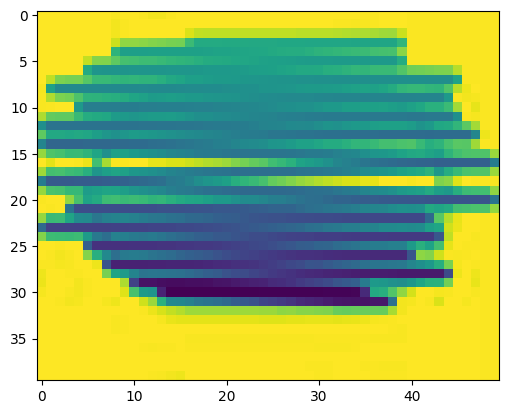

True Label: 0 | Predicted Label: 0


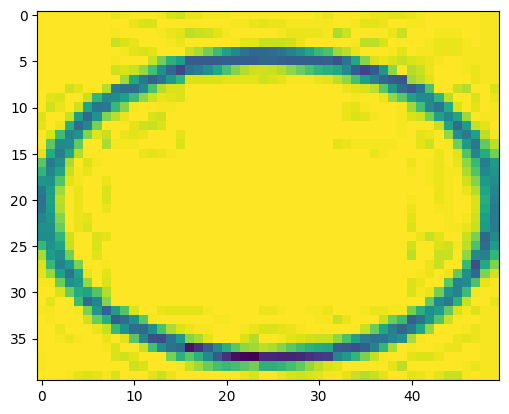

True Label: 0 | Predicted Label: 0


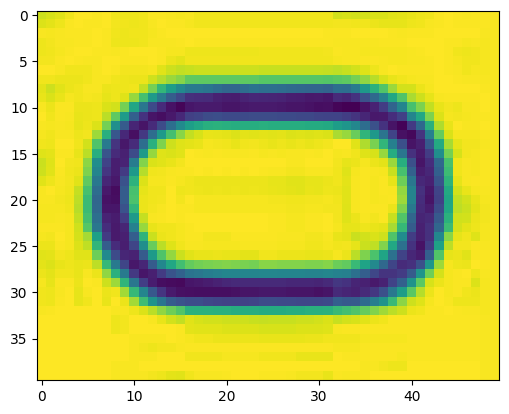

True Label: 1 | Predicted Label: 1


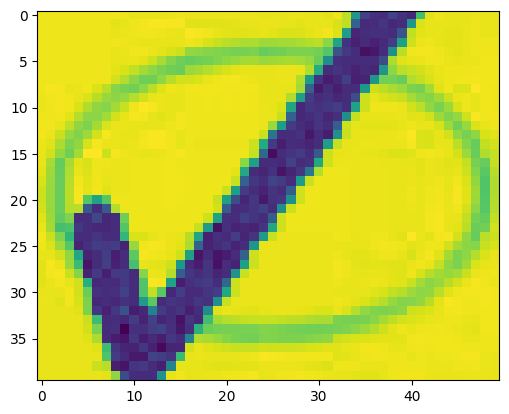

True Label: 1 | Predicted Label: 1


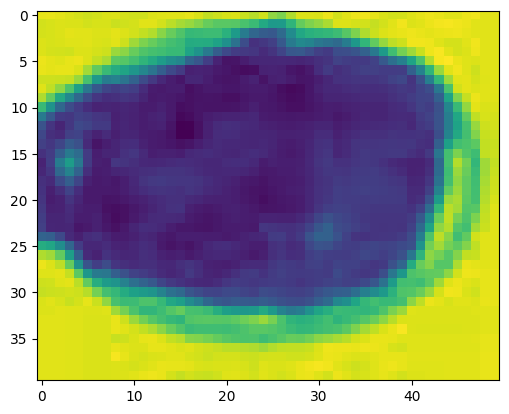

True Label: 0 | Predicted Label: 0


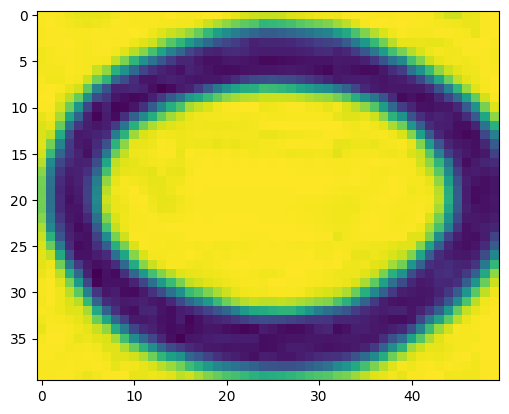

True Label: 1 | Predicted Label: 1


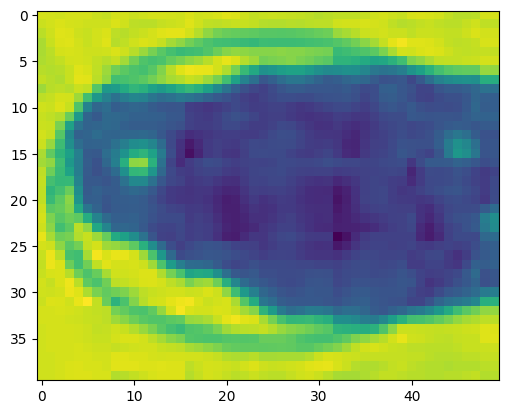

True Label: 0 | Predicted Label: 0


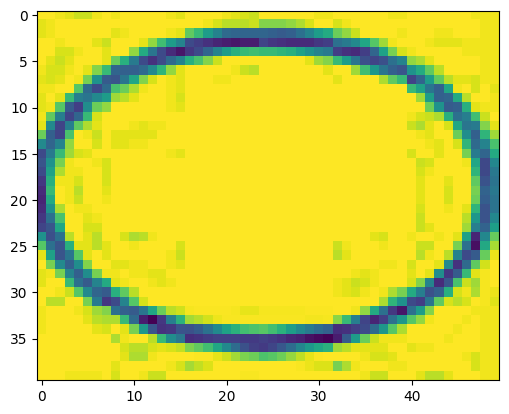

True Label: 0 | Predicted Label: 0


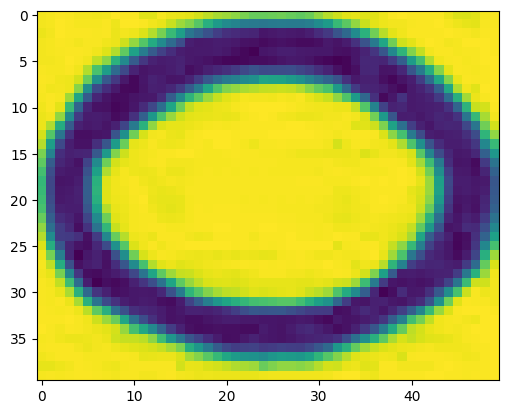

True Label: 0 | Predicted Label: 0


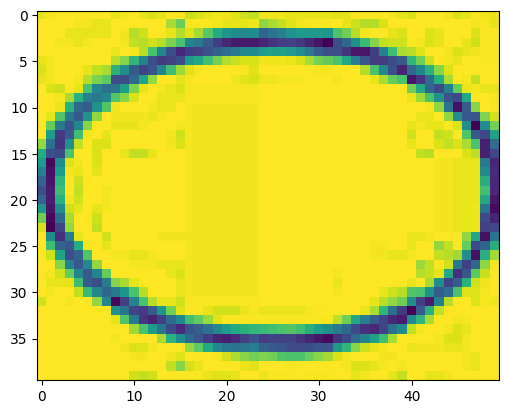

True Label: 0 | Predicted Label: 0


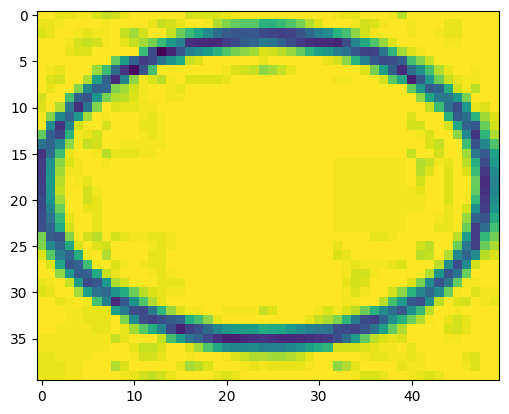

True Label: 1 | Predicted Label: 1


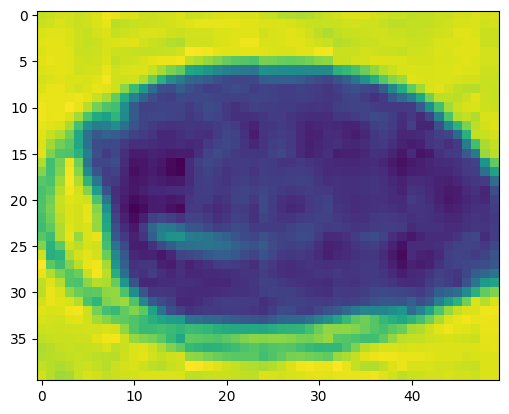

True Label: 1 | Predicted Label: 1


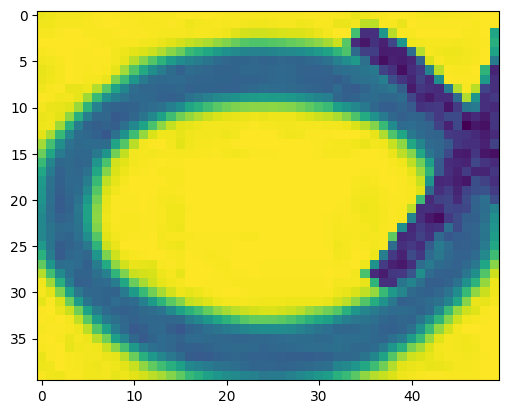

True Label: 0 | Predicted Label: 0


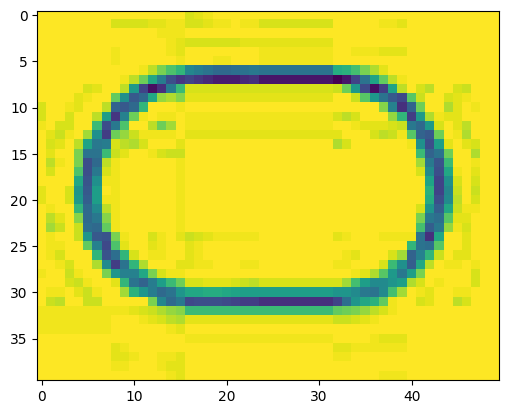

True Label: 1 | Predicted Label: 1


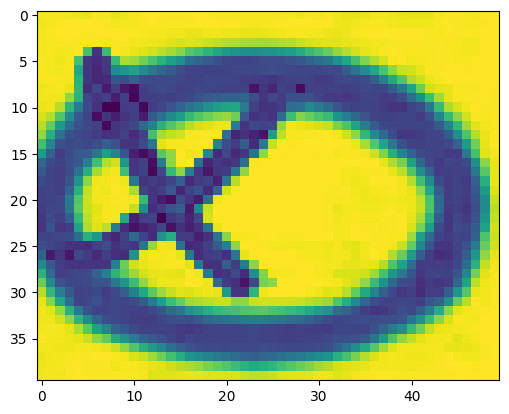

True Label: 0 | Predicted Label: 0


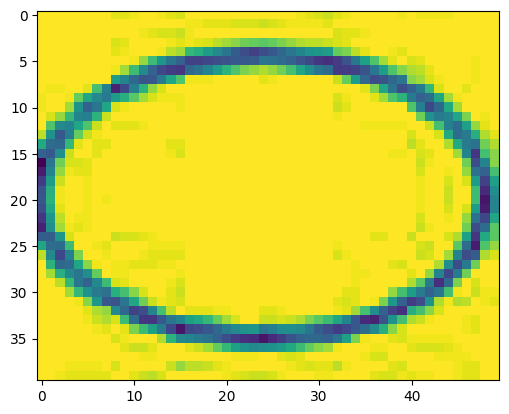

True Label: 0 | Predicted Label: 0


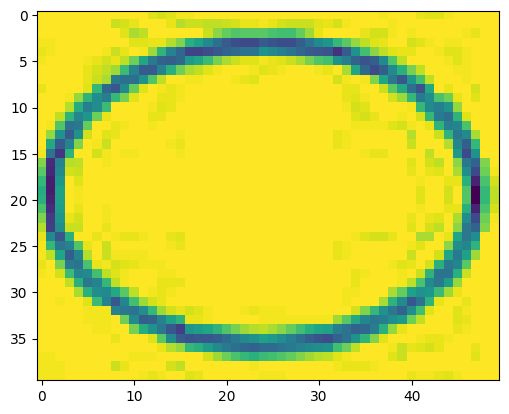

True Label: 1 | Predicted Label: 1


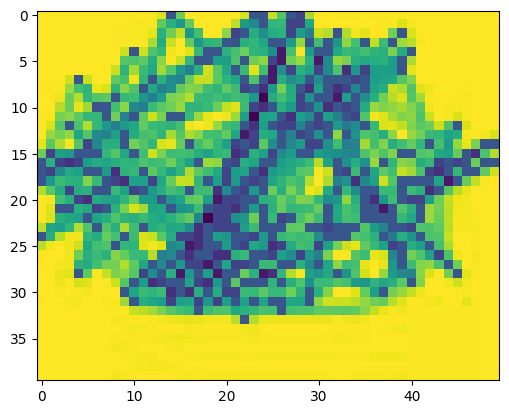

True Label: 1 | Predicted Label: 1


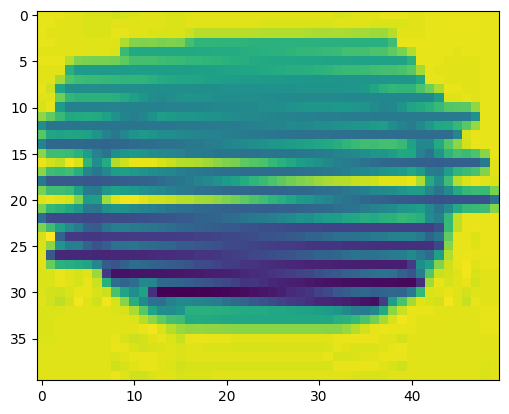

In [6]:
# Plot random predictions from the test set as a grid/sanity check:

# grab random batch from test set
random_batch = next(iter(test_loader))
images, labels = random_batch


with torch.inference_mode():
    images, labels = images.to(device), labels.to(device)
    preds = model(images)
    pred_labels = torch.argmax(preds, dim=1)
    for i in range(len(images)):
        print(f"True Label: {labels[i].item()} | Predicted Label: {pred_labels[i].item()}")
        # You can also visualize the images if needed
        plt.imshow(images[i].cpu().permute(1, 2, 0))
        plt.show()